In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')

print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
print('Null values:\n', df.isnull().sum())

Null values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts before cleaning:')
for col in zero_cols:
    print(f'  {col}: {(df[col] == 0).sum()}')

df[zero_cols] = df[zero_cols].replace(0, np.nan)

for col in zero_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('\nNull values after cleaning:', df.isnull().sum().sum())

Zero counts before cleaning:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0

Null values after cleaning: 0


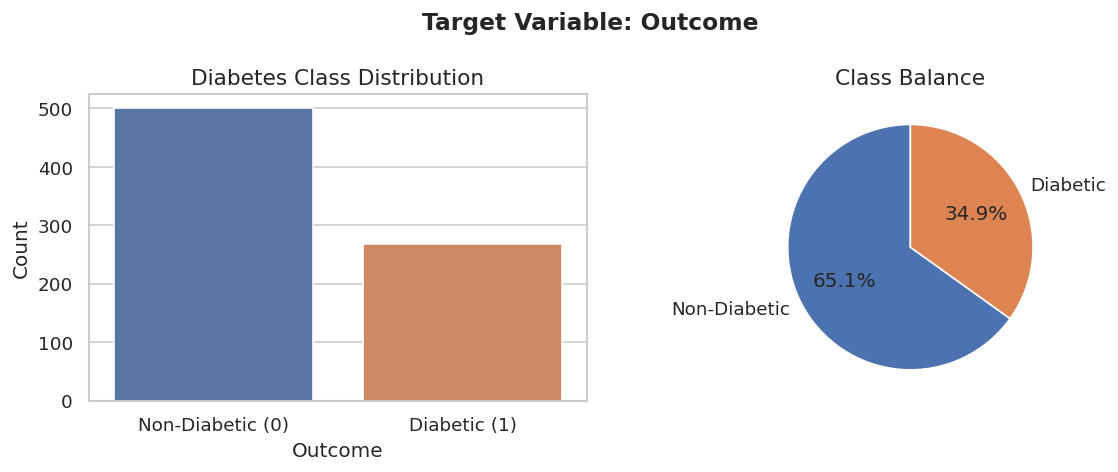

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='Outcome', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Diabetes Class Distribution', fontsize=13)
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
axes[0].set_ylabel('Count')

counts = df['Outcome'].value_counts()
axes[1].pie(counts, labels=['Non-Diabetic', 'Diabetic'], autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Balance', fontsize=13)

plt.suptitle('Target Variable: Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

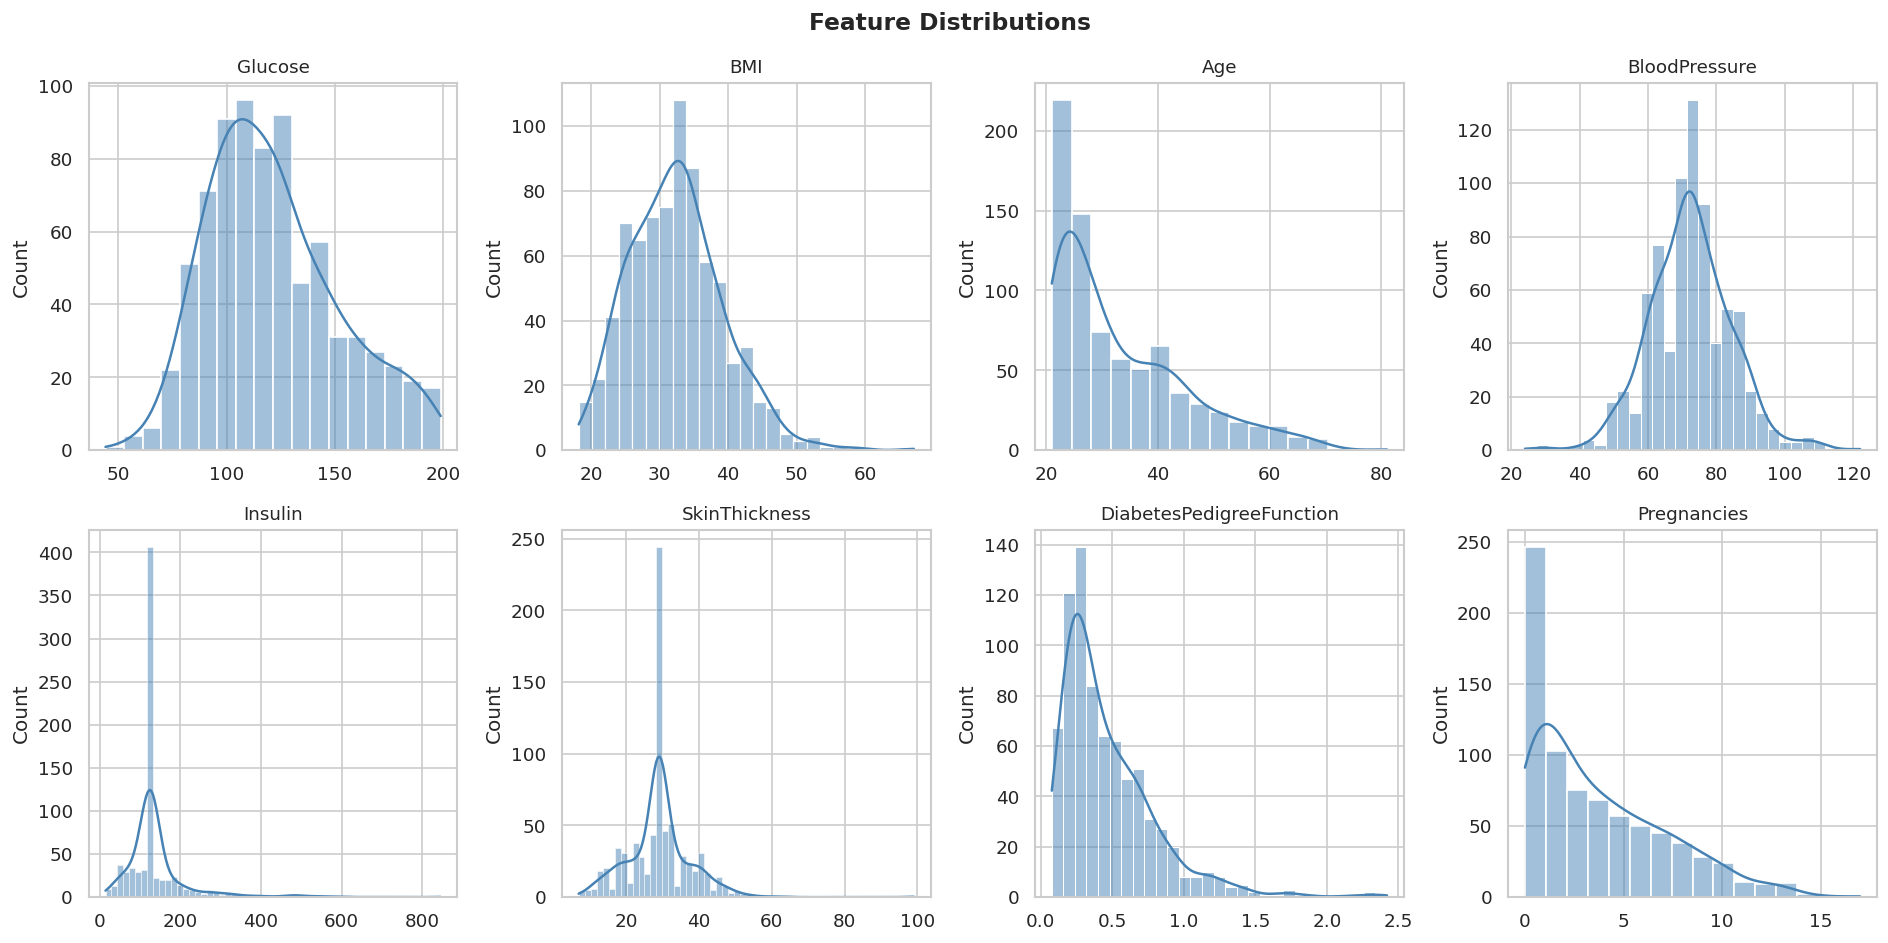

In [10]:
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction', 'Pregnancies']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

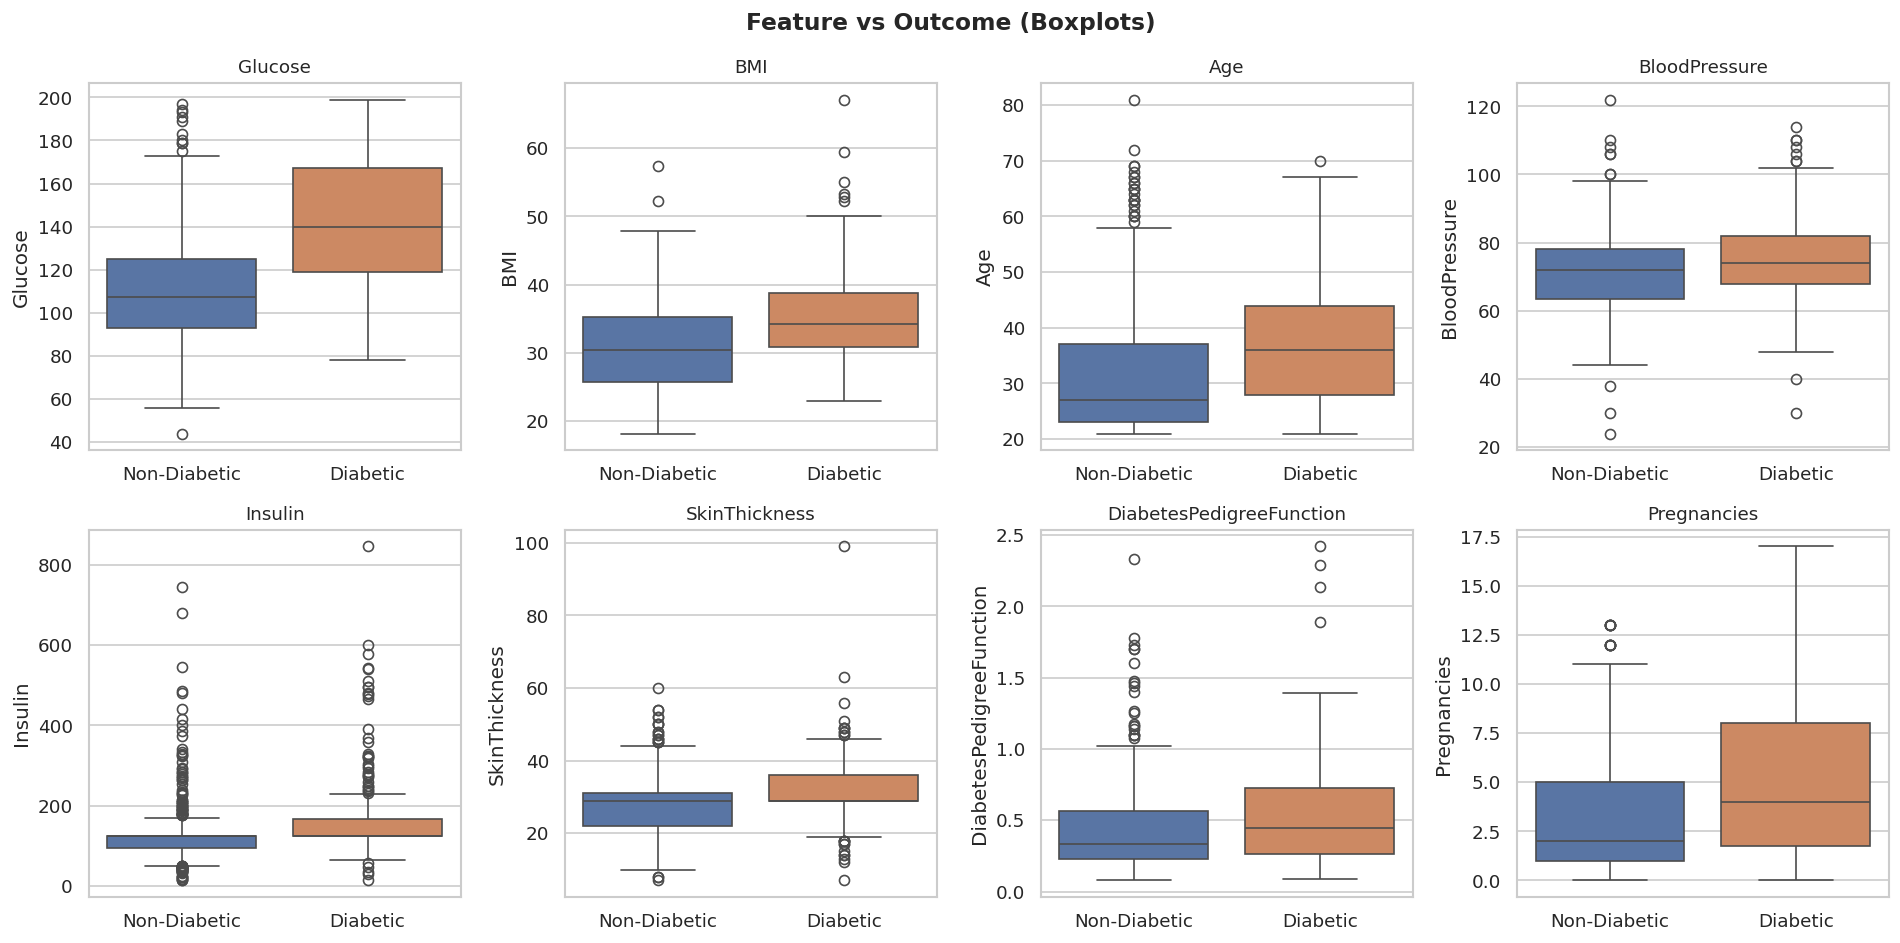

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, palette=['#4C72B0', '#DD8452'], ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])
    axes[i].set_xlabel('')

plt.suptitle('Feature vs Outcome (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

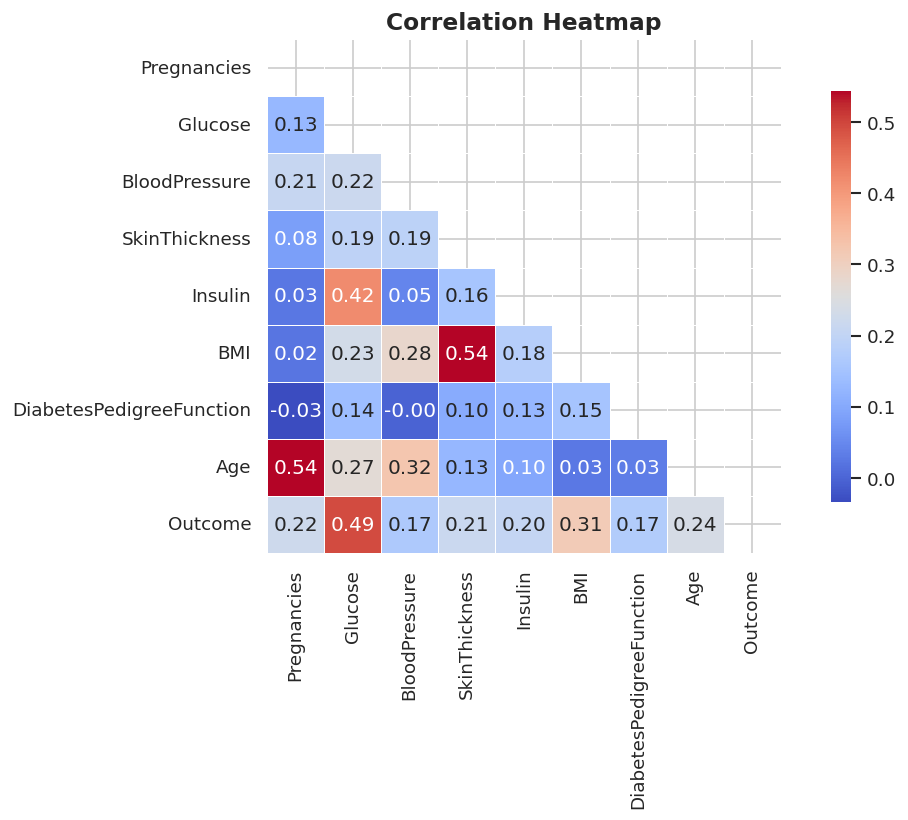

Correlation with Outcome (sorted):
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


In [12]:
plt.figure(figsize=(10, 7))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with Outcome (sorted):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

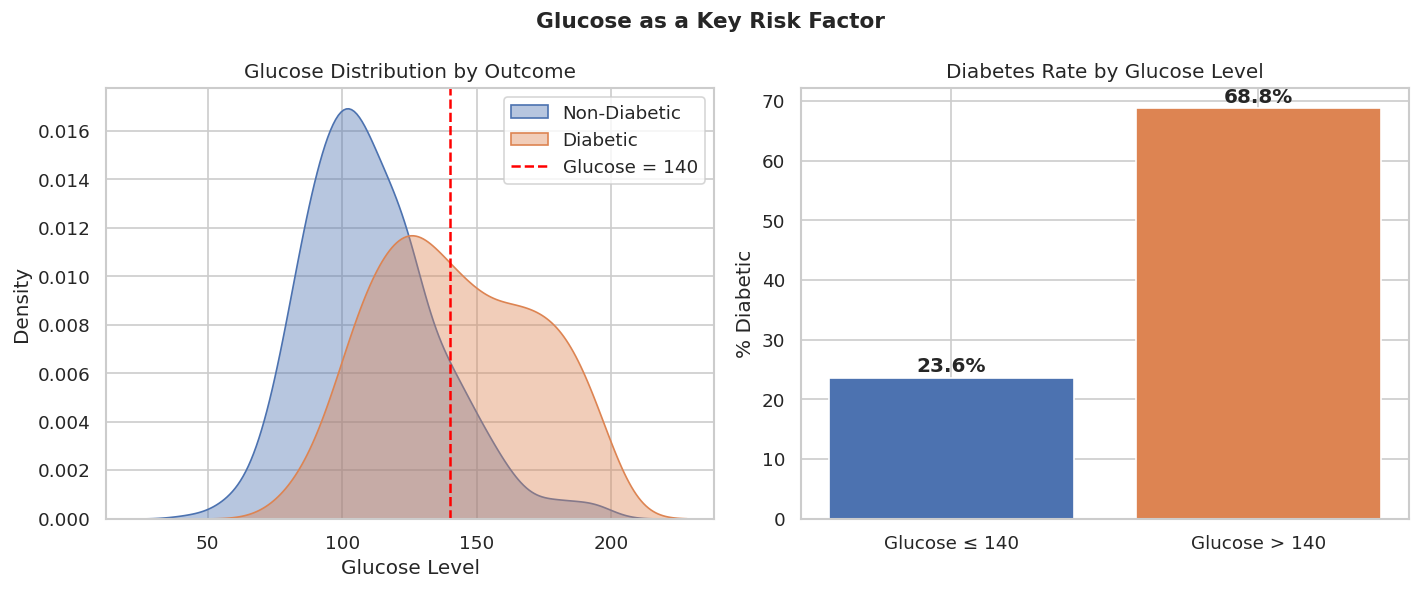

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for outcome, label, color in [(0, 'Non-Diabetic', '#4C72B0'), (1, 'Diabetic', '#DD8452')]:
    sns.kdeplot(df[df['Outcome'] == outcome]['Glucose'],
                label=label, fill=True, alpha=0.4, color=color, ax=axes[0])
axes[0].axvline(x=140, color='red', linestyle='--', label='Glucose = 140')
axes[0].set_title('Glucose Distribution by Outcome', fontsize=12)
axes[0].legend()
axes[0].set_xlabel('Glucose Level')

above_140 = df[df['Glucose'] > 140]
below_140 = df[df['Glucose'] <= 140]
rates = [below_140['Outcome'].mean() * 100, above_140['Outcome'].mean() * 100]

axes[1].bar(['Glucose ≤ 140', 'Glucose > 140'], rates, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_title('Diabetes Rate by Glucose Level', fontsize=12)
axes[1].set_ylabel('% Diabetic')
for i, v in enumerate(rates):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Glucose as a Key Risk Factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

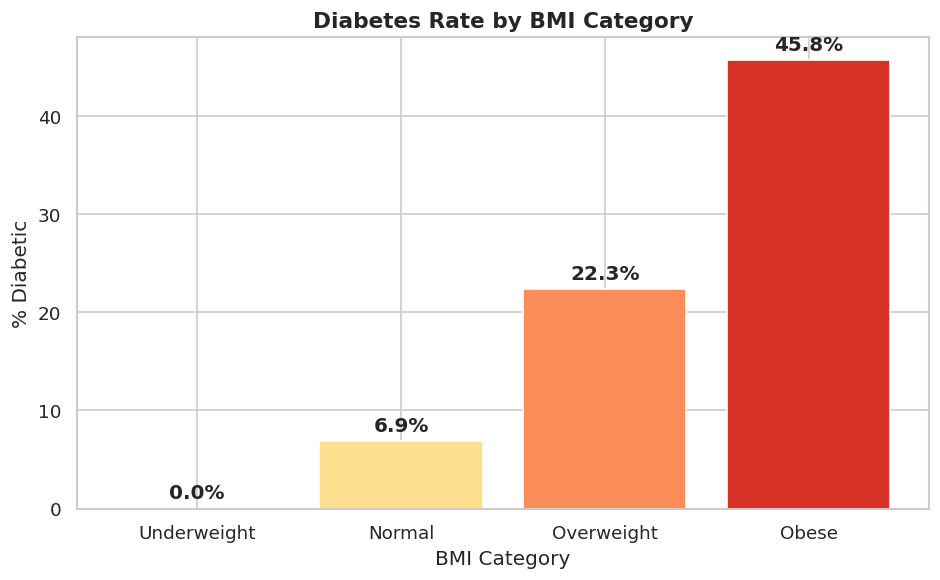

In [15]:
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_diabetes_rate = df.groupby('BMI_Category')['Outcome'].mean() * 100
bmi_diabetes_rate = bmi_diabetes_rate.reindex(bmi_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(bmi_diabetes_rate.index, bmi_diabetes_rate.values,
               color=['#91bfdb', '#fee090', '#fc8d59', '#d73027'], edgecolor='white')
plt.title('Diabetes Rate by BMI Category', fontsize=13, fontweight='bold')
plt.ylabel('% Diabetic')
plt.xlabel('BMI Category')
for bar, val in zip(bars, bmi_diabetes_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

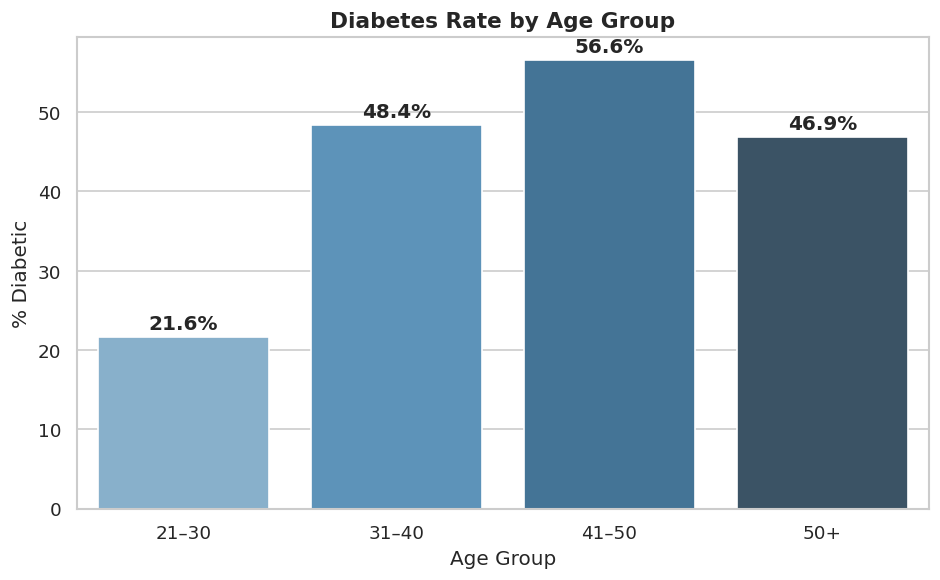

In [16]:
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 100],
                          labels=['21–30', '31–40', '41–50', '50+'])

age_rate = df.groupby('Age_Group')['Outcome'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=age_rate.index, y=age_rate.values, palette='Blues_d')
plt.title('Diabetes Rate by Age Group', fontsize=13, fontweight='bold')
plt.ylabel('% Diabetic')
plt.xlabel('Age Group')
for i, val in enumerate(age_rate.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

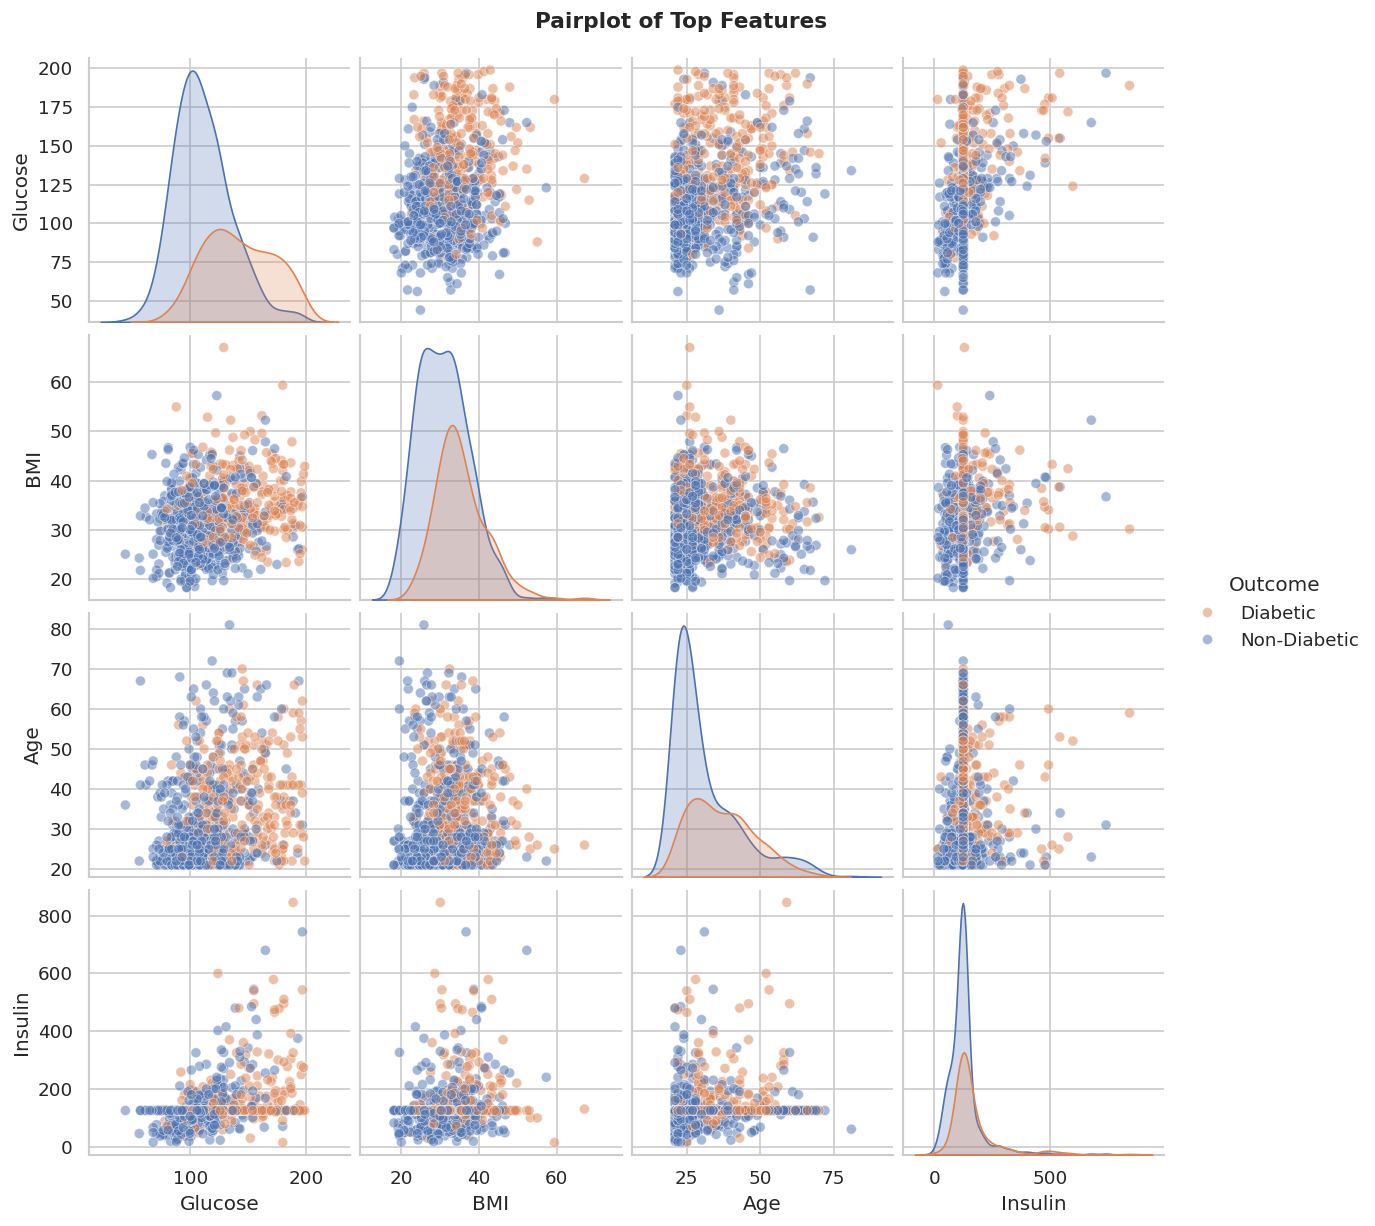

In [17]:
top_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
pair_df = df[top_features].copy()
pair_df['Outcome'] = pair_df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

g = sns.pairplot(pair_df, hue='Outcome',
                 palette={'Non-Diabetic': '#4C72B0', 'Diabetic': '#DD8452'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot of Top Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [20]:
print('=' * 55)
print('       DIABETES RISK FACTOR EDA — KEY INSIGHTS')
print('=' * 55)

total = len(df)
diabetic = df['Outcome'].sum()
print(f'\n📊 Dataset: {total} patient records')
print(f'   Diabetic: {diabetic} ({diabetic/total*100:.1f}%) | Non-Diabetic: {total-diabetic} ({(total-diabetic)/total*100:.1f}%)')

g_above = df[df['Glucose'] > 140]['Outcome'].mean() * 100
g_below = df[df['Glucose'] <= 140]['Outcome'].mean() * 100
print(f'\n🔴 Glucose > 140: {g_above:.1f}% diabetes rate vs {g_below:.1f}% below 140')
print(f'   → Patients with glucose >140 are ~{g_above/g_below:.1f}x more likely to be diabetic')

obese_rate = df[df['BMI_Category'] == 'Obese']['Outcome'].mean() * 100
normal_rate = df[df['BMI_Category'] == 'Normal']['Outcome'].mean() * 100
print(f'\n🟠 Obese patients: {obese_rate:.1f}% diabetes rate vs {normal_rate:.1f}% for Normal BMI')

old_rate = df[df['Age'] > 40]['Outcome'].mean() * 100
young_rate = df[df['Age'] <= 30]['Outcome'].mean() * 100
print(f'\n🟡 Age > 40: {old_rate:.1f}% diabetes rate vs {young_rate:.1f}% for Age ≤ 30')

# Fix: only use numeric columns for correlation
top_corr = df.select_dtypes(include='number').corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print(f'\n📈 Top 3 features correlated with diabetes:')
for feat, val in top_corr.head(3).items():
    print(f'   {feat}: {val:.3f}')

print('\n' + '=' * 55)

       DIABETES RISK FACTOR EDA — KEY INSIGHTS

📊 Dataset: 768 patient records
   Diabetic: 268 (34.9%) | Non-Diabetic: 500 (65.1%)

🔴 Glucose > 140: 68.8% diabetes rate vs 23.6% below 140
   → Patients with glucose >140 are ~2.9x more likely to be diabetic

🟠 Obese patients: 45.8% diabetes rate vs 6.9% for Normal BMI

🟡 Age > 40: 52.6% diabetes rate vs 21.6% for Age ≤ 30

📈 Top 3 features correlated with diabetes:
   Glucose: 0.493
   BMI: 0.312
   Age: 0.238

